# 03 Feature Engineering

Validacion del contrato de features y del preprocesador reusable definido en `src/features/build_features.py`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.ingestion import fetch_sample
from src.features.build_features import CATEGORICAL_FEATURES, MODEL_FEATURE_COLUMNS, NUMERIC_FEATURES, TARGET_COLUMN, get_feature_pipeline, prepare_feature_frame, split_features_target
from src.utils.config import get_settings

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
settings = get_settings()
feature_df = fetch_sample(f"SELECT * FROM {settings.obt_table}", limit=8000, settings=settings)
assert not feature_df.empty, 'La muestra de features esta vacia.'
print('feature sample shape =', feature_df.shape)
print('columns =', feature_df.columns.tolist())
feature_df.head()


feature sample shape = (8000, 12)
columns = ['pickup_datetime', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'passenger_count', 'trip_distance', 'pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id', 'fare_amount']


,pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id,fare_amount
0,2025-01-01 19:11:55,19,3,1,0,1,1.07,161,164,2,1,9.3
1,2025-01-01 19:20:43,19,3,1,0,2,10.22,237,138,2,1,40.8
2,2025-01-01 19:46:11,19,3,1,0,1,1.83,90,114,2,1,10.7
3,2025-01-01 19:12:38,19,3,1,0,1,0.78,233,230,2,1,15.6
4,2025-01-01 19:26:44,19,3,1,0,1,0.20,48,100,1,1,5.8


In [3]:
X_raw, y = split_features_target(feature_df)
X_prepared = prepare_feature_frame(X_raw)
print('raw feature frame =', X_raw.shape)
print('prepared feature frame =', X_prepared.shape)
X_prepared.head()


raw feature frame = (8000, 7)
prepared feature frame = (8000, 10)


,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,passenger_count,trip_distance,pickup_location_id,dropoff_location_id,vendor_id,ratecode_id
0,19,2,1,0,1,1.07,161,164,2,1
1,19,2,1,0,2,10.22,237,138,2,1
2,19,2,1,0,1,1.83,90,114,2,1
3,19,2,1,0,1,0.78,233,230,2,1
4,19,2,1,0,1,0.20,48,100,1,1


In [4]:
missing_model_cols = sorted(set(MODEL_FEATURE_COLUMNS).difference(X_prepared.columns))
assert not missing_model_cols, f'Faltan columnas de modelado: {missing_model_cols}'
feature_contract = pd.DataFrame({
    'feature': MODEL_FEATURE_COLUMNS,
    'role': ['numeric temporal', 'numeric temporal', 'numeric temporal', 'numeric temporal', 'numeric trip', 'numeric trip', 'categorical location', 'categorical location', 'categorical operator', 'categorical operator']
})
feature_contract


,feature,role
0,pickup_hour,numeric temporal
1,pickup_dayofweek,numeric temporal
2,pickup_month,numeric temporal
3,is_weekend,numeric temporal
4,passenger_count,numeric trip
5,trip_distance,numeric trip
6,pickup_location_id,categorical location
7,dropoff_location_id,categorical location
8,vendor_id,categorical operator
9,ratecode_id,categorical operator


In [5]:
X_prepared[NUMERIC_FEATURES].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
pickup_hour,8000.0,13.351125,4.985323,0.0,0.0,6.0,13.0,22.0,23.0,23.0
pickup_dayofweek,8000.0,2.782125,0.412828,2.0,2.0,2.0,3.0,3.0,3.0,3.0
pickup_month,8000.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
is_weekend,8000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
passenger_count,8000.0,1.4545,0.90196,1.0,1.0,1.0,1.0,4.0,5.0,6.0
trip_distance,8000.0,3.846771,5.057296,0.01,0.2498,0.5,1.78,17.2,20.5,65.95


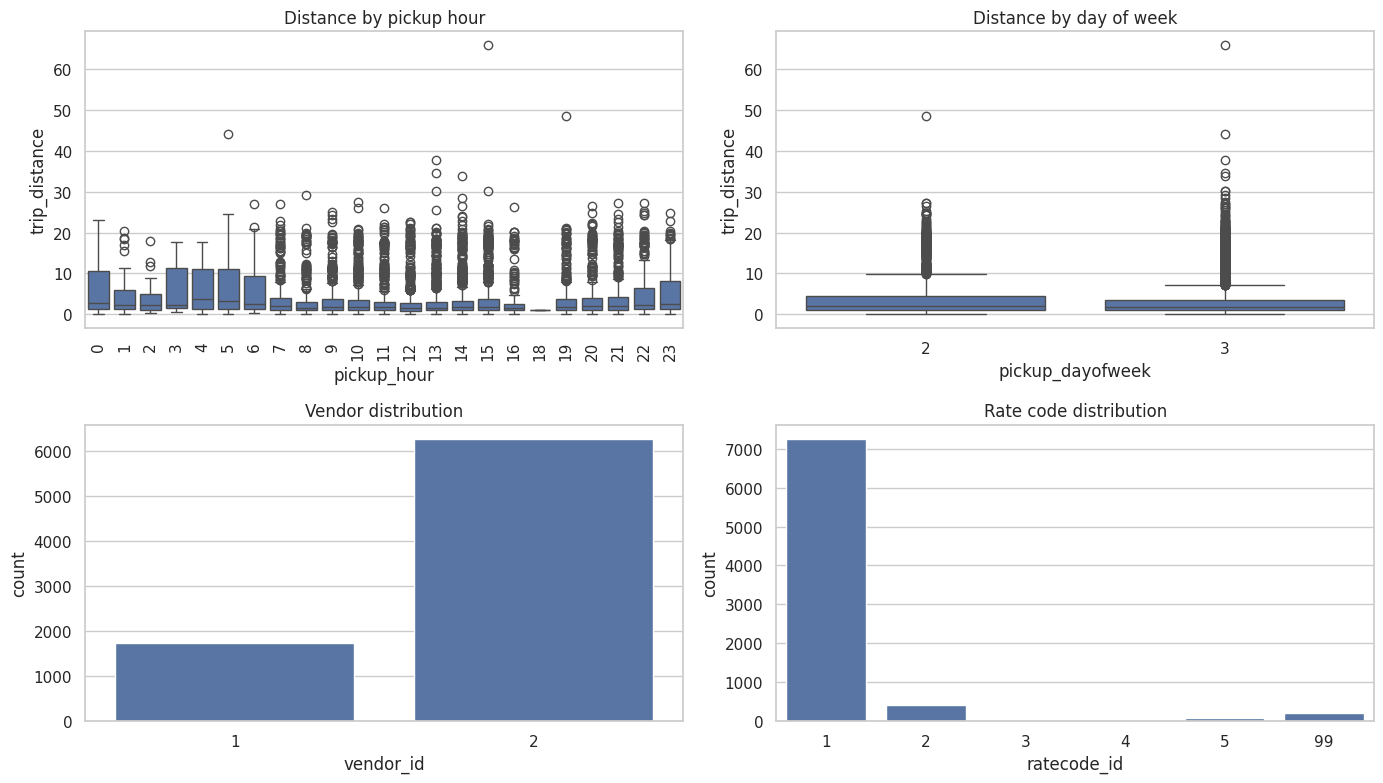

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=X_prepared, x='pickup_hour', y='trip_distance', ax=axes[0, 0])
axes[0, 0].set_title('Distance by pickup hour')
axes[0, 0].tick_params(axis='x', rotation=90)
sns.boxplot(data=X_prepared, x='pickup_dayofweek', y='trip_distance', ax=axes[0, 1])
axes[0, 1].set_title('Distance by day of week')
sns.countplot(data=X_prepared, x='vendor_id', ax=axes[1, 0])
axes[1, 0].set_title('Vendor distribution')
sns.countplot(data=X_prepared, x='ratecode_id', ax=axes[1, 1])
axes[1, 1].set_title('Rate code distribution')
plt.tight_layout()


In [7]:
pipeline = get_feature_pipeline()
X_transformed = pipeline.fit_transform(X_raw, y)
print('numeric features =', NUMERIC_FEATURES)
print('categorical features =', CATEGORICAL_FEATURES)
print('transformed shape =', X_transformed.shape)


numeric features = ['pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'passenger_count', 'trip_distance']
categorical features = ['pickup_location_id', 'dropoff_location_id', 'vendor_id', 'ratecode_id']
transformed shape = (8000, 386)


In [8]:
pd.Series(y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


count    8000.000000
mean       20.668015
std        20.027041
min         0.010000
1%          4.400000
5%          5.800000
50%        13.500000
95%        70.000000
99%        86.007000
max       417.400000
Name: fare_amount, dtype: float64

## Conclusiones esperadas

- El pipeline de features debe depender solo de columnas seguras ya presentes en la OBT.
- Cualquier cambio al set de features debe reflejarse en `src/features/build_features.py`.
